# Modélisation - Classification Endométriose

Comparaison de 5 modèles de classification pour prédire le diagnostic d'endométriose :
1. **Logistic Regression**
2. **K-Nearest Neighbors**
3. **Support Vector Machine**
4. **Random Forest**
5. **Gradient Boosting**

**Métriques d'évaluation :** Accuracy, Precision, Recall, F1-score, ROC-AUC.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (10, 6)
RANDOM_STATE = 42

## 1. Chargement et préparation des données

In [2]:
df = pd.read_csv("../data/structured_endometriosis_data.csv")
print(df.shape)
df.head()

(10000, 7)


,Age,Menstrual_Irregularity,Chronic_Pain_Level,Hormone_Level_Abnormality,Infertility,BMI,Diagnosis
0,24,1,8.361531,0,0,19.451314,0
1,37,1,4.995508,0,0,22.388436,0
2,46,1,3.363996,1,0,21.320443,0
3,32,1,5.246037,0,0,20.177715,1
4,28,1,3.898932,1,0,23.538103,1


In [3]:
X = df.drop(columns=["Diagnosis"])
y = df["Diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train : {X_train.shape} - Test : {X_test.shape}")
print(f"Répartition classes train : {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Répartition classes test  : {y_test.value_counts(normalize=True).round(3).to_dict()}")

Train : (8000, 6) - Test : (2000, 6)
Répartition classes train : {0: 0.592, 1: 0.408}
Répartition classes test  : {0: 0.592, 1: 0.408}


## 2. Définition des pipelines

Chaque modèle est encapsulé dans un `Pipeline` avec un `StandardScaler`. `class_weight='balanced'` est utilisé lorsque disponible pour gérer le déséquilibre de classes.

In [4]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=7))
    ]),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    "Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE))
    ]),
}

## 3. Validation croisée

Stratified K-Fold (k=5) avec F1-score pour tenir compte du déséquilibre.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:25s} F1 = {scores.mean():.4f} (+/- {scores.std():.4f})")

Logistic Regression       F1 = 0.5683 (+/- 0.0061)


KNN                       F1 = 0.4538 (+/- 0.0187)


SVM                       F1 = 0.5719 (+/- 0.0128)


Random Forest             F1 = 0.4516 (+/- 0.0183)


Gradient Boosting         F1 = 0.4389 (+/- 0.0145)


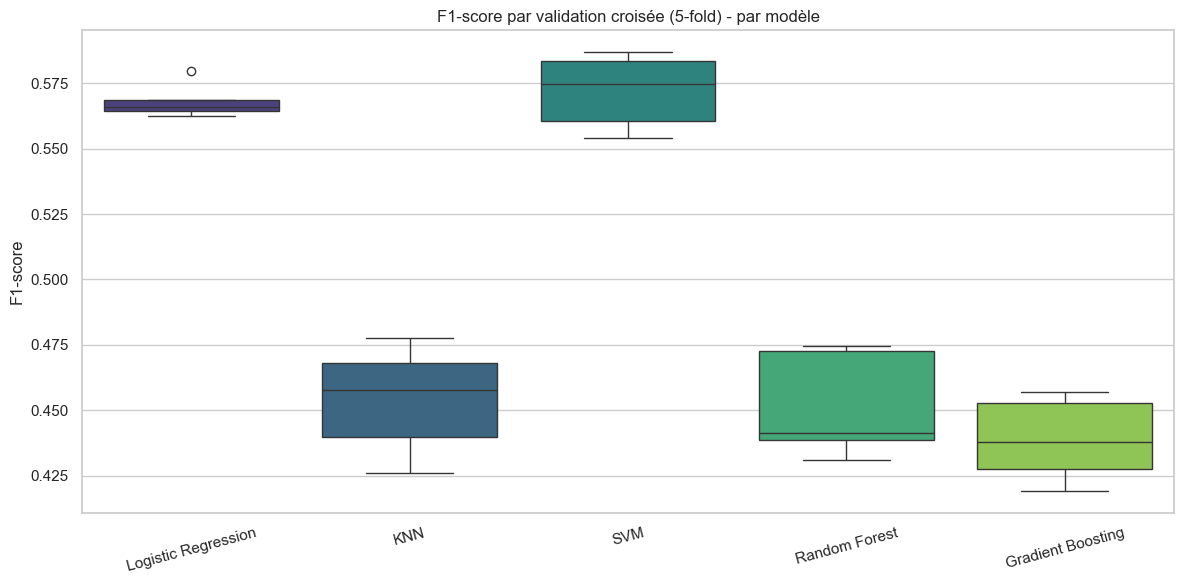

In [6]:
cv_df = pd.DataFrame(cv_results)

plt.figure(figsize=(12, 6))
sns.boxplot(data=cv_df, palette="viridis")
plt.title("F1-score par validation croisée (5-fold) - par modèle")
plt.ylabel("F1-score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 4. Entraînement et évaluation sur le test set

In [7]:
results = []
trained_models = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    trained_models[name] = pipe

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results).set_index("Model").round(4)
results_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.6095,0.5172,0.6434,0.5735,0.6575
KNN,0.5945,0.5035,0.4363,0.4675,0.6003
SVM,0.6075,0.5149,0.6569,0.5773,0.6422
Random Forest,0.6030,0.5159,0.4375,0.4735,0.6032
Gradient Boosting,0.6195,0.5518,0.3591,0.4350,0.6380


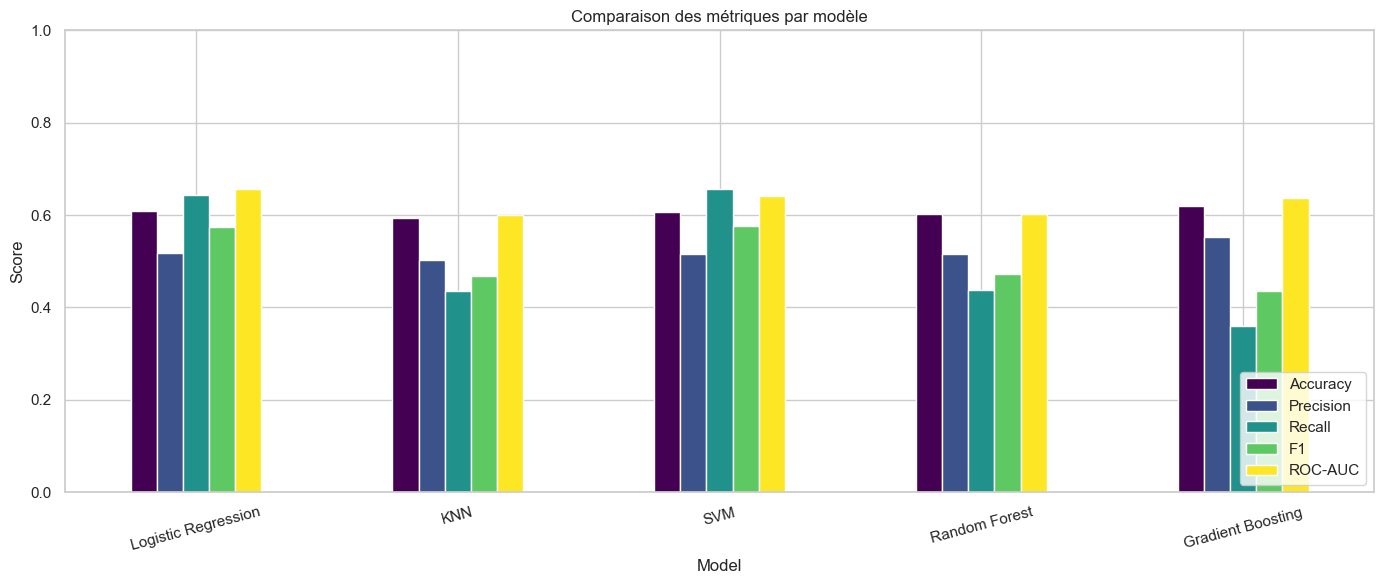

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))
results_df.plot(kind="bar", ax=ax, colormap="viridis")
ax.set_title("Comparaison des métriques par modèle")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 5. Courbes ROC

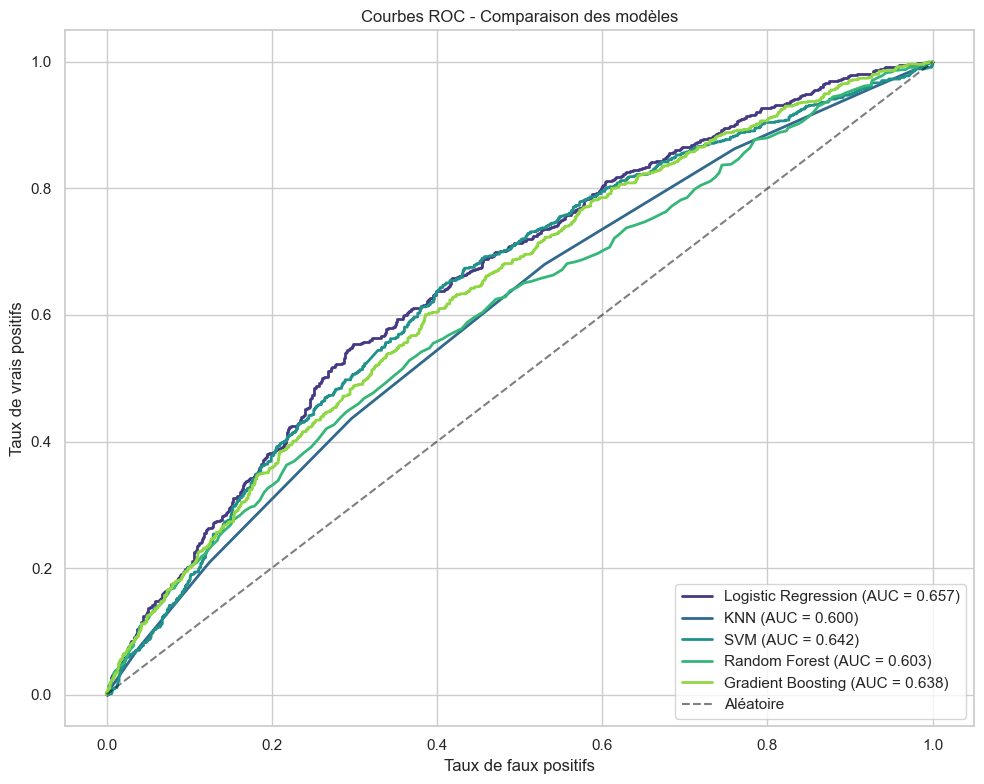

In [9]:
plt.figure(figsize=(10, 8))
colors = sns.color_palette("viridis", len(trained_models))

for (name, pipe), color in zip(trained_models.items(), colors):
    y_proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", color=color, linewidth=2)

plt.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Aléatoire")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbes ROC - Comparaison des modèles")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 6. Matrices de confusion

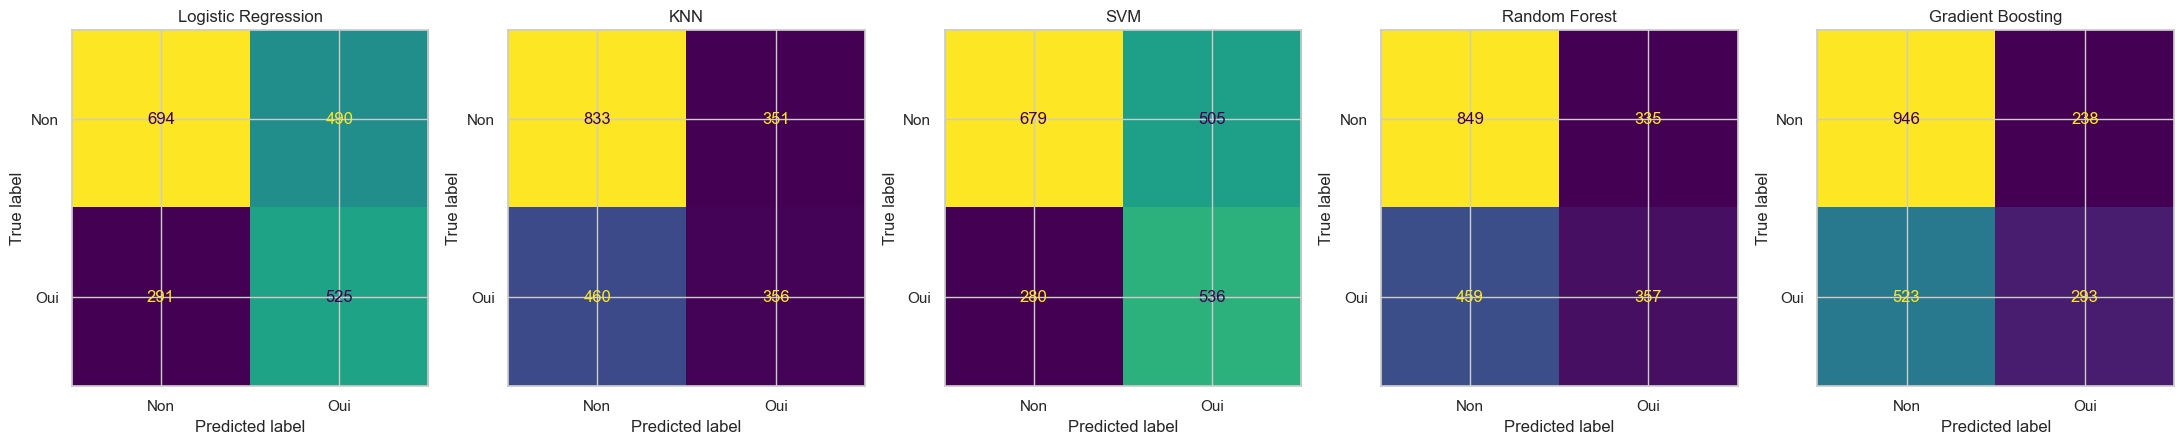

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))
for ax, (name, pipe) in zip(axes, trained_models.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Non", "Oui"]).plot(
        ax=ax, cmap="viridis", colorbar=False
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()

## 7. Meilleur modèle - Analyse détaillée

In [11]:
best_model_name = results_df["F1"].idxmax()
best_model = trained_models[best_model_name]
print(f"Meilleur modèle (F1) : {best_model_name}\n")

y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["Pas d'endométriose", "Endométriose"]))

Meilleur modèle (F1) : SVM



                    precision    recall  f1-score   support

Pas d'endométriose       0.71      0.57      0.63      1184
      Endométriose       0.51      0.66      0.58       816

          accuracy                           0.61      2000
         macro avg       0.61      0.62      0.61      2000
      weighted avg       0.63      0.61      0.61      2000



## 8. Importance des variables

Pour les modèles tree-based, on peut extraire l'importance des variables.

/var/folders/kr/qn8bq3254gg0x4nt_l1gbpfc0000gn/T/ipykernel_94675/2018760048.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, ax=ax, palette="viridis")
/var/folders/kr/qn8bq3254gg0x4nt_l1gbpfc0000gn/T/ipykernel_94675/2018760048.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, ax=ax, palette="viridis")


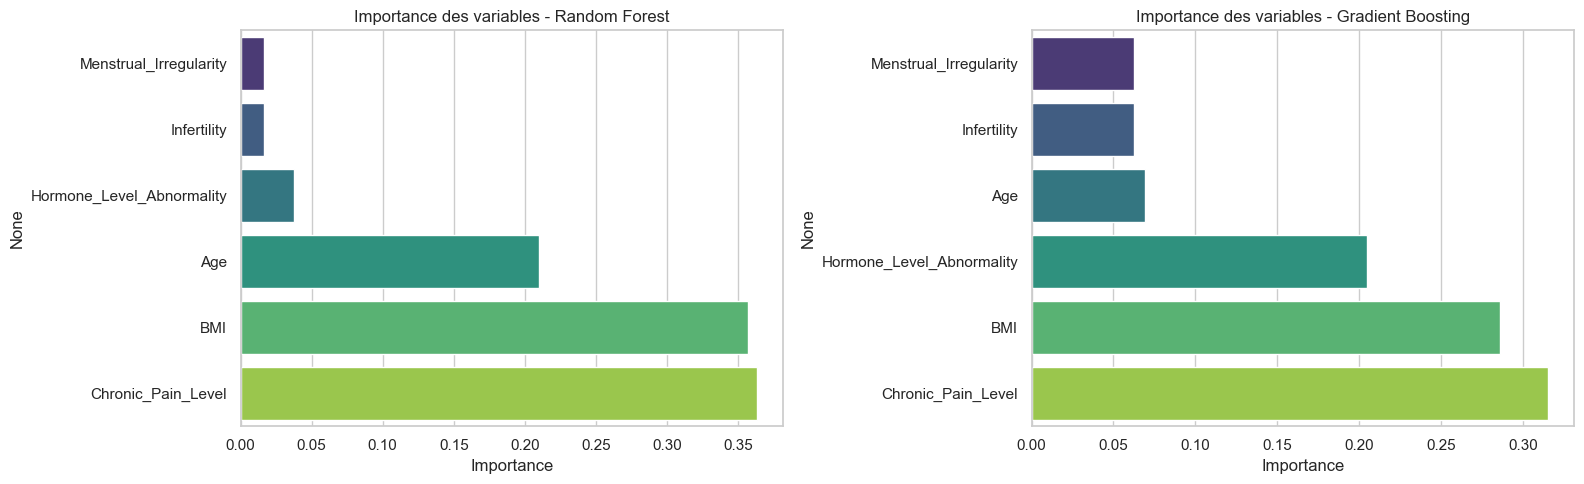

In [12]:
tree_models = ["Random Forest", "Gradient Boosting"]
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, name in zip(axes, tree_models):
    clf = trained_models[name].named_steps["clf"]
    importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=True)
    sns.barplot(x=importances.values, y=importances.index, ax=ax, palette="viridis")
    ax.set_title(f"Importance des variables - {name}")
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

## 9. Conclusion

- Les modèles sont comparés sur un ensemble de test stratifié (20 %).
- Le classement final est basé sur le F1-score (compromis précision/rappel pertinent pour un diagnostic médical).
- `Chronic_Pain_Level` et les symptômes binaires ressortent comme les variables les plus discriminantes.
- Des pistes d'amélioration : optimisation des hyperparamètres (GridSearchCV), ajustement du seuil de décision, et exploration de modèles plus avancés (XGBoost, LightGBM) si besoin.